# Comma Restoration with Token Classification using BERT
This notebook fine-tunes a transformer encoder (e.g., mBERT, LvBERT) to restore commas in text as a token classification task. Each token receives one of two labels: COMMA (a comma should follow this word) or O (no comma). At inference time, existing commas are stripped, labels are predicted, and the sentence is rebuilt by inserting commas after tokens predicted as COMMA.

Models to try:
- https://huggingface.co/google-bert/bert-base-multilingual-cased
- https://huggingface.co/AiLab-IMCS-UL/lvbert
- https://huggingface.co/FacebookAI/xlm-roberta-base
- https://huggingface.co/EMBEDDIA/litlat-bert
- https://huggingface.co/jhu-clsp/mmBERT-small

# Prepare environment

In [1]:
!python -V
!pip -V
!pip install numpy transformers[torch] scikit-learn datasets torch tiktoken blobfile protobuf sentencepiece wandb

import torch
print("CUDA device:", torch.cuda.get_device_name(0))
print("FP16 supported:", torch.cuda.get_device_capability(0)[0] >= 7)
print("BF16 supported:", torch.cuda.is_bf16_supported())

Python 3.12.11
pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)
CUDA device: Tesla T4
FP16 supported: True
BF16 supported: True


In [2]:
import json
import os
import re
from dataclasses import dataclass

import numpy as np
import requests
import torch
from datasets import load_dataset, DatasetDict
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from torch.utils.data import DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
    set_seed,
)
import wandb

In [3]:
# Authenticate with Weights & Biases to enable logging and experiment tracking
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: artursz to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# Prepare dataset
Raw sentences from the Latvian Universal Dependencies (LVTB) corpus: https://universaldependencies.org/treebanks/lv_lvtb/index.html


In [4]:
def fetch_ud_texts(split):
    conllu = requests.get(f"https://raw.githubusercontent.com/UniversalDependencies/UD_Latvian-LVTB/r2.16/lv_lvtb-ud-{split}.conllu").text
    texts = [line[9:].strip() for line in conllu.splitlines() if line.startswith("# text = ")]
    return texts


def filter_by_token_count(texts, tokenizer_name_or_path: str = "google-bert/bert-base-multilingual-cased", max_tokens: int = 120):
    kept = []
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name_or_path)
    for t in texts:
        ids = tokenizer(t, add_special_tokens=True, truncation=False)["input_ids"]
        if len(ids) <= max_tokens:
            kept.append(t)
    return kept


def prepare_data(data_dir='data'):
    # Download UD Latvian splits, filter by mBERT token count, and save plain .txt files.
    os.makedirs(data_dir, exist_ok=True)

    dev_texts = fetch_ud_texts("dev")
    train_texts = fetch_ud_texts("train")

    # Filter out long ones to avoid truncation
    dev_texts_filtered = filter_by_token_count(dev_texts)
    train_texts_filtered = filter_by_token_count(train_texts)
    print(f'DEV: {len(dev_texts)} -> {len(dev_texts_filtered)} after filtering by token count')
    print(f'TRAIN: {len(train_texts)} -> {len(train_texts_filtered)} after filtering by token count')

    with open(os.path.join(data_dir, "dev.txt"), "w", encoding="utf-8") as f:
        for t in dev_texts_filtered: f.write(t + "\n")
    with open(os.path.join(data_dir, "train.txt"), "w", encoding="utf-8") as f:
        for t in train_texts_filtered: f.write(t + "\n")

    return dev_texts_filtered, train_texts_filtered

dev_texts, train_texts = prepare_data()

print(*train_texts[:5], sep='\n')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1178 > 512). Running this sequence through the model will result in indexing errors


DEV: 2080 -> 2047 after filtering by token count
TRAIN: 15055 -> 14921 after filtering by token count
Hēra valda augstajā Olimpā.
Viņa, tāpat kā viņas vīrs Zevs, ir pavēlniece pār pērkoniem un zibeņiem; paklausot viņas vārdam, tumšo lietus mākoņi klāj debesis, un viņas rokas mājiens rada drausmīgas vētras.
Daiļa ir diženā Hēra- lielām acīm, lillijbaltām rokām, ar vainagu uz brīnišķīgajām, viļņainajām cirtām; valdonīgi, mierīgi un majestātiski mirdz viņas acis.
Majestātiska savā garajā, krāšņajā pašas Atēnas austajā tērpā, viņa brauc lejup no Olimpa ratos, kuros ir iejūgti 2 nemirstīgi zirgi.
No tīra sudraba ir rati, no tīra zelta ir riteņi, bet riteņu spieķi mirdz varā kalti.


# Tokenization

In [5]:
def tokenize(s):
    # Tokenizes string into words and punctuation tokens.
    return re.findall(r'\s*(?:\w+|\S)', s)

def tokenize_with_comma_labels(s):
    tokens_with_labels = re.findall(r'(\s*\w+|[^\s,])\s*(,+)?', s)
    tokens_with_labels = [(tok, 'COMMA' if comma else 'O') for tok, comma in tokens_with_labels]
    return tokens_with_labels

def remove_commas(s) -> str:
    return re.sub(r'\s*,+\s*', ' ', s)

In [6]:
def test_tokenization(model=None):
  s = 'Vēl 9% sacīja, ka nav izlēmuši kā balsot, bet 3,2% atteicās atbildēt.'
  print(tokenize(s))
  print(tokenize_with_comma_labels(s))
  print(remove_commas(s))

  if model:
    print('Tokenizer stats', model)
    t = AutoTokenizer.from_pretrained(model)
    print('Encoded sample:', t(s))
    print('Encoded sample - subword units:', t.convert_ids_to_tokens(t.encode(s)))
    lengths = sorted([len(t.encode(seq)) for seq in train_texts])
    print('Vocab size:', t.vocab_size)
    print(f'Max length: {max(lengths)}')
    print(f'Min length: {min(lengths)}')
    print(f'Avg length: {sum(lengths) / len(lengths)}')
    print(f'95% length: {lengths[int(len(lengths) * 0.95)]}')
    print(f'99% length: {lengths[int(len(lengths) * 0.99)]}')

test_tokenization("AiLab-IMCS-UL/lvbert")
test_tokenization("jhu-clsp/mmBERT-small")

['Vēl', ' 9', '%', ' sacīja', ',', ' ka', ' nav', ' izlēmuši', ' kā', ' balsot', ',', ' bet', ' 3', ',', '2', '%', ' atteicās', ' atbildēt', '.']
[('Vēl', 'O'), ('9', 'O'), ('%', 'O'), ('sacīja', 'COMMA'), (' ka', 'O'), ('nav', 'O'), ('izlēmuši', 'O'), ('kā', 'O'), ('balsot', 'COMMA'), (' bet', 'O'), ('3', 'COMMA'), ('2', 'O'), ('%', 'O'), ('atteicās', 'O'), ('atbildēt', 'O'), ('.', 'O')]
Vēl 9% sacīja ka nav izlēmuši kā balsot bet 3 2% atteicās atbildēt.
Tokenizer stats AiLab-IMCS-UL/lvbert


tokenizer_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Encoded sample: {'input_ids': [2, 574, 684, 70, 417, 5, 16, 35, 29811, 24, 4622, 5, 27, 168, 5, 146, 70, 6862, 4850, 6, 3], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}
Encoded sample - subword units: ['[CLS]', 'Vēl', '9', '%', 'sacīja', ',', 'ka', 'nav', 'izlēmuši', 'kā', 'balsot', ',', 'bet', '3', ',', '2', '%', 'atteicās', 'atbildēt', '.', '[SEP]']
Vocab size: 32004
Max length: 105
Min length: 3
Avg length: 23.420213122444878
95% length: 48
99% length: 62
['Vēl', ' 9', '%', ' sacīja', ',', ' ka', ' nav', ' izlēmuši', ' kā', ' balsot', ',', ' bet', ' 3', ',', '2', '%', ' atteicās', ' atbildēt', '.']
[('Vēl', 'O'), ('9', 'O'), ('%', 'O'), ('sacīja', 'COMMA'), (' ka', 'O'), ('nav', 'O'), ('izlēmuši', 'O'), ('kā', 'O'), ('balsot', 'COMMA'), (' bet', 'O'), ('3', 'COMMA'), ('2', 'O'), ('%', 'O'), ('atteicās', 'O'), ('atbildēt', 'O'), ('.', 'O')]
Vēl 9% sacīja ka nav izl

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Encoded sample: {'input_ids': [2, 744, 229673, 235248, 235315, 235358, 6817, 236073, 1663, 235269, 5675, 5103, 9417, 135924, 2704, 27536, 52635, 70402, 562, 235269, 1285, 235248, 235304, 235269, 235284, 235358, 41643, 520, 28688, 696, 137369, 235265, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}
Encoded sample - subword units: ['<bos>', '▁V', 'ēl', '▁', '9', '%', '▁sac', 'ī', 'ja', ',', '▁ka', '▁nav', '▁iz', 'lē', 'mu', 'ši', '▁kā', '▁bals', 'ot', ',', '▁bet', '▁', '3', ',', '2', '%', '▁atte', 'ic', 'ās', '▁at', 'bildēt', '.', '<eos>']
Vocab size: 256000
Max length: 147
Min length: 3
Avg length: 37.97855371623886
95% length: 82
99% length: 105


In [7]:
LABELS = ["O", "COMMA"]
LABEL2ID = {name: i for i, name in enumerate(LABELS)}
ID2LABEL = {i: name for i, name in enumerate(LABELS)}

In [8]:
# Tokenize text into subwords and align word-level labels to the correct subword positions

def tokenize_and_align_labels(tokenizer, words, word_labels=None, label2id=None, debug=False, return_tensors=None):
    # Tokenize with word boundaries preserved
    enc = tokenizer(
        list(words),
        is_split_into_words=True,
        add_special_tokens=True,
        return_tensors=return_tensors,
        truncation=False
    )

    # Map each token back to its source word index
    word_ids = enc.word_ids()  # one per token position (None for specials)

    # Figure out which token is the last subword of each word. Assign word labels only there; others get -100.
    # HF Trainer and loss functions (like cross-entropy) automatically ignore -100, so you don't need to modify loss computation.
    if word_labels is not None:
        IGNORE = -100
        labels = [IGNORE] * len(word_ids)
        for i, wid in enumerate(word_ids):
            if wid is None:
                continue
            next_wid = word_ids[i+1] if i+1 < len(word_ids) else None
            if wid != next_wid:
                # last subword of this word: assign the word label
                labels[i] = label2id[word_labels[wid]]
    else:
        labels = None

    if debug:
        input_ids = enc["input_ids"]
        if return_tensors == "pt":
            input_ids = input_ids.tolist()[0]
        print("WORDS:         ", words)
        print("WORD_LABELS:   ", word_labels)
        print("WORD_IDS:      ", word_ids)
        print("TOKEN_IDS:     ", input_ids)
        print("TOKENS:        ", tokenizer.convert_ids_to_tokens(input_ids))
        print("ALIGNED_LABELS:", labels)

    # enc.labels = labels
    # return enc
    r = {
        'input_ids': enc['input_ids'],
        "attention_mask": enc["attention_mask"],
    }
    if labels is not None:
        if return_tensors == "pt":
            labels = torch.tensor([labels], dtype=torch.long)
        r['labels'] = labels
    return r

print(tokenize_and_align_labels(AutoTokenizer.from_pretrained("AiLab-IMCS-UL/lvbert"), *zip(*tokenize_with_comma_labels("Viens, divi.")), LABEL2ID, debug=True))

WORDS:          ('Viens', ' divi', '.')
WORD_LABELS:    ('COMMA', 'O', 'O')
WORD_IDS:       [None, 0, 1, 2, None]
TOKEN_IDS:      [2, 1394, 516, 6, 3]
TOKENS:         ['[CLS]', 'Viens', 'divi', '.', '[SEP]']
ALIGNED_LABELS: [-100, 1, 0, 0, -100]
{'input_ids': [2, 1394, 516, 6, 3], 'attention_mask': [1, 1, 1, 1, 1], 'labels': [-100, 1, 0, 0, -100]}


# Tokenize and format dataset for model training and evaluation

In [9]:
def build_datasets(tokenizer, train_file, validation_file, train_samples=None, validation_samples=None, seed=42, max_tokens=None, label2id=None) -> DatasetDict:
    ds = load_dataset("text", data_files={"train": train_file, "validation": validation_file})

    if train_samples:
        ds["train"] = ds["train"].shuffle(seed=seed).take(train_samples)
    if validation_samples:
        ds["validation"] = ds["validation"].shuffle(seed=seed).take(validation_samples)

    def _map(example):
        words, word_labels = zip(*tokenize_with_comma_labels(example['text']))
        return tokenize_and_align_labels(tokenizer, words=words, word_labels=word_labels, label2id=label2id)

    ds_tokenized = ds.map(_map, remove_columns=ds["train"].column_names)
    # ds_tokenized = ds.map(_map)

    if max_tokens is not None:
        ds_tokenized = ds_tokenized.filter(lambda ex: len(ex["input_ids"]) <= max_tokens)

    return ds_tokenized

tok = AutoTokenizer.from_pretrained("AiLab-IMCS-UL/lvbert")
ds = build_datasets(tok, 'data/train.txt', 'data/dev.txt', train_samples=2, validation_samples=2, label2id=LABEL2ID)
loader = DataLoader(ds['train'], batch_size=2, shuffle=False, collate_fn=DataCollatorForTokenClassification(tok))
batch = next(iter(loader))
print(batch)

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

{'input_ids': tensor([[    2,   196,  4657,  1263,  6673,  9557,   112,   173,    54,    52,
          4539,     8,   620,    30,     9,   526,    80,   215,   158,   791,
          2772,    52, 12448,   787, 27593,     6,     9,     3],
        [    2,   129,    38,    33,   134,  6483,  6874,   207,    69, 21187,
            33,  1814,  1070,     6,     3,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0]]), 'labels': tensor([[-100,    0, -100, -100,    0, -100, -100, -100,    0,    0,    0,    0,
            0,    0,    0,    1,    0,    0,    0,    0,    0, -100, -100,    0,
            0,    0,    0, -100],
        [-100,    0,    0,    0,    0,    0,    0,    1,    0,    0,    0,    0,
            0,    0, -1

# Metrics for token classification.
*Accuracy* can be misleading for imbalanced tasks:
  - In our data, most tokens are "O" (no comma).
  - A dumb model that always predicts "O" could reach very high accuracy (e.g. 95%+) simply by never predicting commas at all.

*F1-score* (the harmonic mean of precision and recall) specifically for the COMMA class gives a more honest view of model quality:
  - Precision: when the model predicts COMMA, is it right?
  - Recall: does the model catch most of the true commas?
  - F1: balances both, penalizing if one is much lower.

In [10]:
def compute_metrics_fn(p):
    # Model outputs: shape [batch_size, seq_len, num_labels]
    # -> pick the most likely label for each token
    preds = np.argmax(p.predictions, axis=-1)

    # True labels: shape [batch_size, seq_len]
    labels = p.label_ids

    # Flatten but skip positions marked with -100
    y_true = []
    y_pred = []
    for true_seq, pred_seq in zip(labels, preds):
        for t, p_ in zip(true_seq, pred_seq):
            if t == -100:
                continue
            y_true.append(t)
            y_pred.append(p_)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred,
        average="binary", pos_label=1, # for binary classification (COMMA vs O)
        # average="micro", # for multi-class classification
    )
    acc = accuracy_score(y_true, y_pred)
    return {
        'f1': f1,
        'p': precision,
        'r': recall,
        'acc': acc,
    }

# Inference
Given plain text, we strip commas, tokenize with word boundaries, run the model, and insert commas after tokens labeled COMMA.

In [11]:
def process_text(text, model, tokenizer):
    #  Preprocess: remove commas (should not be present), split into words
    text = remove_commas(text)

    # Tokenize with subword alignment
    words = tokenize(text)
    enc = tokenizer(
        words,
        is_split_into_words=True,
        add_special_tokens=True,
        return_tensors="pt",
        truncation=False
    )
    word_ids = enc.word_ids()
    # Move to correct device
    device = next(model.parameters()).device
    enc = {k: v.to(device) for k, v in enc.items()}

    # Forward pass
    model.eval()
    with torch.no_grad():
        logits = model(**enc).logits  # [1, seq_len, label_count]
        pred_ids = torch.argmax(logits, dim=-1).squeeze(0).tolist()

    # Collapse subwords -> last subword gets the label
    word_preds = {}
    for i, wid in enumerate(word_ids):
        if wid is None:  # skip [CLS], [SEP], etc.
            continue
        next_wid = word_ids[i + 1] if i + 1 < len(word_ids) else None
        if wid != next_wid:  # last subword of the word
            word_preds[wid] = pred_ids[i]

    # Return word-level predictions
    results = [(w, model.config.id2label[word_preds[i]]) for i, w in enumerate(words)]
    output_text = "".join([w + ("," if label == "COMMA" else "") for w, label in results])
    return output_text


def process_text_file(model_path_or_name, text_file_path, out_json=None, limit=None):
    model = AutoModelForTokenClassification.from_pretrained(model_path_or_name)
    tokenizer = AutoTokenizer.from_pretrained(model_path_or_name)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    with open(text_file_path, "r", encoding="utf-8") as f:
        texts = [line.strip() for line in f if line.strip()]
    if limit:
        texts = texts[:limit]

    results = []
    for text in texts:
        result = process_text(text, model, tokenizer)
        results.append(result)
        print('---', 'DIFF' if text != result else 'SAME')
        print('REF:', text)
        print('HYP:', result)

    if out_json:
        data = [{"ref": text, "hyp": pred} for text, pred in zip(texts, results)]
        with open(out_json, "w", encoding="utf-8") as f:
            json.dump(data, f, ensure_ascii=False, indent=2)

# Model fine-tuning
- Track loss curves, gradient norms, and evaluation metrics over time
- Use an appropriate optimizer and learning rate schedule (e.g., warmup + decay)
- Watch for overfitting (gap between train and eval performance)
- Adjust batch size, accumulation steps, or precision (fp16/bf16) if needed
- Save best checkpoints based on validation metric (e.g., F1)

In [15]:
def main():
  SEED = 42
  MODEL_NAME_OR_PATH = "AiLab-IMCS-UL/lvbert"
  OUTPUT_DIR = 'models/punctuator'

  set_seed(SEED)
  tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME_OR_PATH)

  # Load dataset
  ds = build_datasets(
      tokenizer,
      'data/train.txt', 'data/dev.txt',
      train_samples=None,
      validation_samples=None,
      max_tokens=200,
      label2id=LABEL2ID,
      seed=SEED
  )

  # Initialize base model for tokenize classification task
  def model_init():
      m = AutoModelForTokenClassification.from_pretrained(
          MODEL_NAME_OR_PATH,
          num_labels=len(LABELS),
          id2label=ID2LABEL,
          label2id=LABEL2ID,
      )

      # Freeze the encoder (base model) and only train the classifier head.
      # m.base_model.requires_grad_(False)
      # # Unfreeze classifier head
      # for p in m.classifier.parameters():
      #     p.requires_grad = True

      return m

  # Define training hyperparameters
  training_args = TrainingArguments(
      output_dir=OUTPUT_DIR,
      learning_rate=1e-5,
      lr_scheduler_type='linear',
      per_device_train_batch_size=16,
      per_device_eval_batch_size=32,
      num_train_epochs=3,
      eval_strategy="epoch",
      save_strategy="epoch",
      load_best_model_at_end=True,
      metric_for_best_model="f1",
      greater_is_better=True,
      warmup_ratio=0.05,
      gradient_accumulation_steps=1,
      fp16=True,

      logging_steps=50,
      report_to='wandb',
  )

  trainer = Trainer(
      model_init=model_init,
      args=training_args,
      train_dataset=ds["train"],
      eval_dataset=ds["validation"],
      processing_class=tokenizer,
      data_collator=DataCollatorForTokenClassification(tokenizer=tokenizer),
      compute_metrics=compute_metrics_fn,
  )

  # Actual training
  trainer.train()
  trainer.save_model(OUTPUT_DIR)
  tokenizer.save_pretrained(OUTPUT_DIR)

  print("\n=== DEMO ===")
  sample_text = 'Vēl 9% sacīja, ka nav izlēmuši kā balsot, bet 3,2% atteicās atbildēt.'
  print("Original: ", sample_text)
  stripped = remove_commas(sample_text)
  print("Stripped: ", stripped)
  restored = process_text(sample_text, trainer.model, tokenizer)
  print("Restored: ", restored)

try:
    import wandb
    with wandb.init():
        main()
finally:
    wandb.finish()

Some weights of BertForTokenClassification were not initialized from the model checkpoint at AiLab-IMCS-UL/lvbert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForTokenClassification were not initialized from the model checkpoint at AiLab-IMCS-UL/lvbert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,P,R,Acc
1,0.048600,0.054285,0.912916,0.940445,0.886953,0.984003
2,0.032500,0.054286,0.919899,0.929583,0.910416,0.985011
3,0.019700,0.062726,0.923354,0.934791,0.912193,0.985683



=== DEMO ===
Original:  Vēl 9% sacīja, ka nav izlēmuši kā balsot, bet 3,2% atteicās atbildēt.
Stripped:  Vēl 9% sacīja ka nav izlēmuši kā balsot bet 3 2% atteicās atbildēt.
Restored:  Vēl 9% sacīja, ka nav izlēmuši, kā balsot, bet 3, 2% atteicās atbildēt.


eval/acc,▁▅█
eval/f1,▁▆█
eval/loss,▁▁█
eval/p,█▁▄
eval/r,▁██
eval/runtime,▁█▆
eval/samples_per_second,█▁▃
eval/steps_per_second,█▁▃
train/epoch,▁▁▁▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇████
train/global_step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇███
+3,...


# Inference

In [ ]:
m = AutoModelForTokenClassification.from_pretrained('models/punctuator')
t = AutoTokenizer.from_pretrained('models/punctuator')
process_text('Viens, divi, trīs. Pārdots par 23,34 EUR.', m ,t)

# Hyperparameter optimization
- Use smaller experiments (1 epoch, limited data) for faster iteration  
- Try random or Bayesian search for hyperparameter tuning  
- Limit training/eval samples when testing setups  
- Scale up once the pipeline works end-to-end  

In [11]:
def main():
  SEED = 42
  MODEL_NAME_OR_PATH = "AiLab-IMCS-UL/lvbert"
  OUTPUT_DIR = 'models/punctuator'

  set_seed(SEED)

  tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME_OR_PATH)

  ds = build_datasets(
      tokenizer,
      'data/train.txt', 'data/dev.txt',
      train_samples=1000,
      validation_samples=100,
      max_tokens=200,
      label2id=LABEL2ID,
      seed=SEED
  )

  def model_init():
      return AutoModelForTokenClassification.from_pretrained(
          MODEL_NAME_OR_PATH,
          num_labels=len(LABELS),
          id2label=ID2LABEL,
          label2id=LABEL2ID,
      )

  training_args = TrainingArguments(
      output_dir=OUTPUT_DIR,
      learning_rate=3e-5,
      lr_scheduler_type='constant_with_warmup',
      per_device_train_batch_size=16,
      per_device_eval_batch_size=32,
      num_train_epochs=1,
      eval_strategy="epoch",
      metric_for_best_model="f1",
      greater_is_better=True,
      warmup_ratio=0.06,
      gradient_accumulation_steps=1,
      fp16=True,

      logging_steps=50,
      report_to='wandb',
  )

  trainer = Trainer(
      model_init=model_init,
      args=training_args,
      train_dataset=ds["train"],
      eval_dataset=ds["validation"],
      processing_class=tokenizer,
      data_collator=DataCollatorForTokenClassification(tokenizer=tokenizer),
      compute_metrics=compute_metrics_fn,
  )

  def wandb_hp_space(_trial):
    return {
        "method": "bayes",
        "metric": {"name": "loss", "goal": "minimize"},
        "parameters": {
            "learning_rate": {"distribution": "log_uniform_values", "min": 1e-6, "max": 1e-3},
        },
    }

  trainer.hyperparameter_search(
      backend="wandb",
      hp_space=wandb_hp_space,
      n_trials=5,
  )

try:
    import wandb
    main()
finally:
    wandb.finish()

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/100 [00:00<?, ? examples/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at AiLab-IMCS-UL/lvbert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

wandb: Agent Starting Run: n0cwcs5n with config:
wandb: 	learning_rate: 1.928744651026975e-05


Trying to set _wandb in the hyperparameter search but there is no corresponding field in `TrainingArguments`.
Trying to set assignments in the hyperparameter search but there is no corresponding field in `TrainingArguments`.
Trying to set metric in the hyperparameter search but there is no corresponding field in `TrainingArguments`.
Some weights of BertForTokenClassification were not initialized from the model checkpoint at AiLab-IMCS-UL/lvbert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).


Epoch,Training Loss,Validation Loss,F1,P,R,Acc
1,0.240400,0.083477,0.857143,0.895161,0.822222,0.972450


eval/acc,▁
eval/f1,▁
eval/loss,▁
eval/p,▁
eval/r,▁
eval/runtime,▁
eval/samples_per_second,▁
eval/steps_per_second,▁
train/epoch,▁██
train/global_step,▁██
+3,...


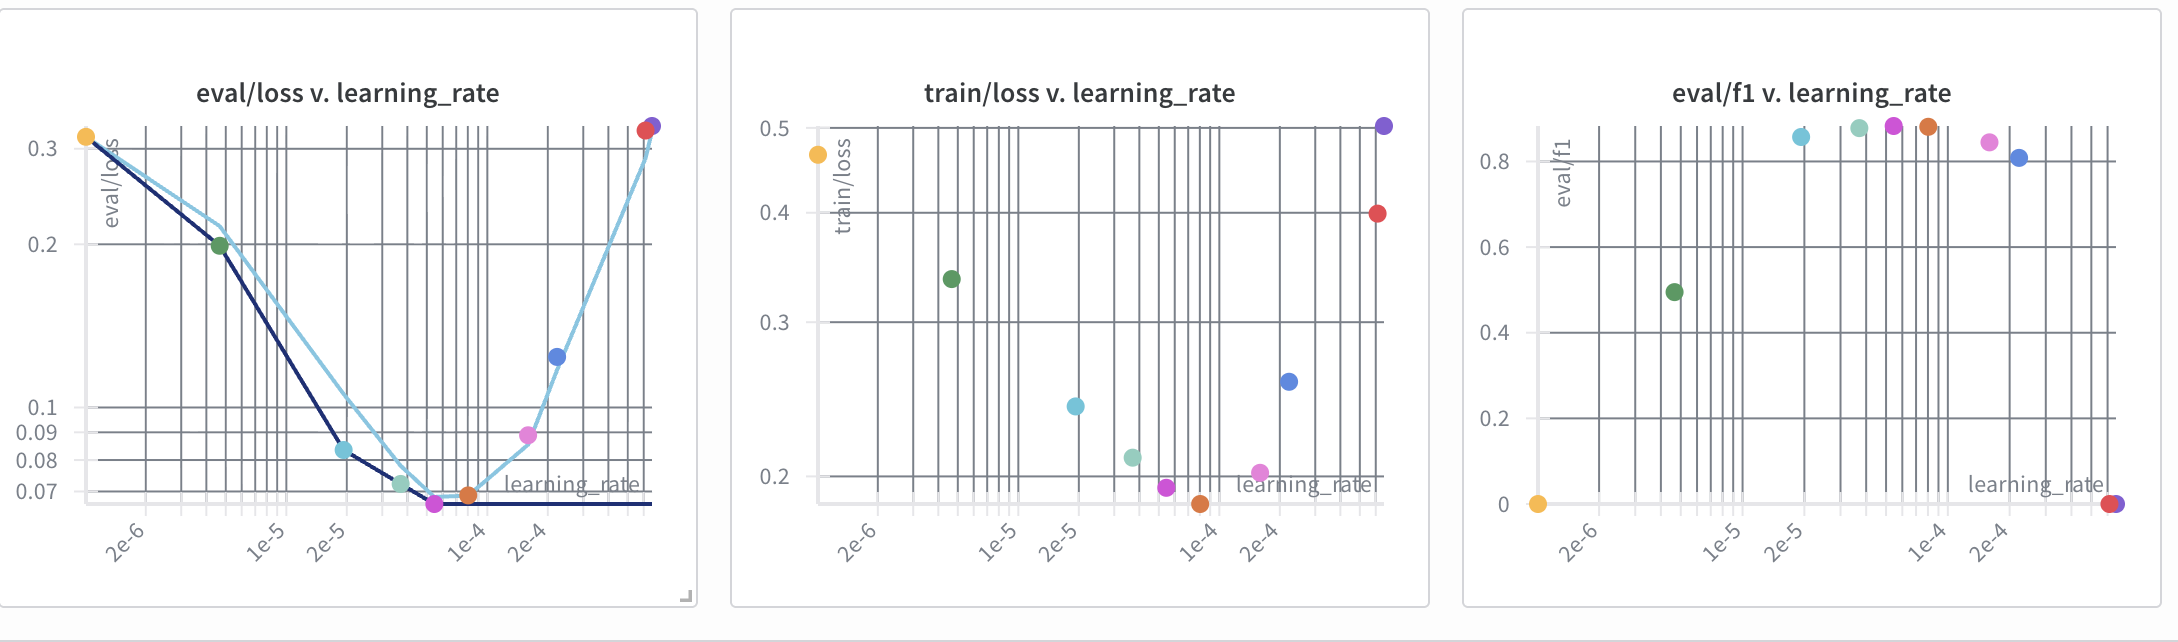